In [5]:
# Watershed is an image segmentation algorithm that treats pixel intensity as elevation (like a topographic map). Here's how it works:
# Concept — imagine flooding a landscape from the lowest points. Where two "flood regions" would merge, a watershed boundary (dam) is built. Those dams become the segment borders.
# Problem it solves — separating touching or overlapping objects that a simple threshold can't split (e.g., coins touching each other).

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def display(img, cmap='gray'):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

In [8]:
sep_point = cv.imread('../data/pennies.jpg')

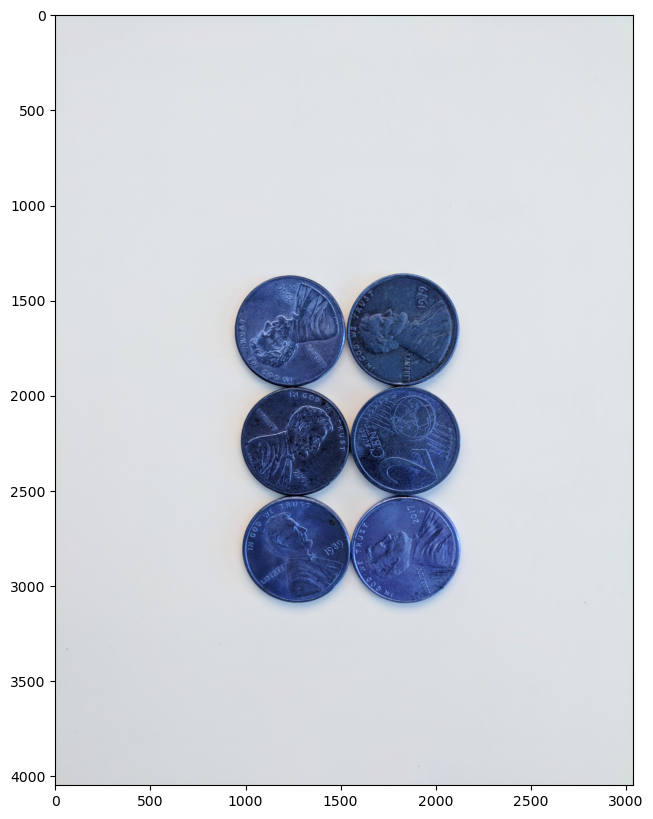

In [9]:
display(sep_point)

In [20]:
# Medium blurr
sep_blur = cv.medianBlur(sep_point, 25)
sep_blur = cv.cvtColor(sep_blur, cv.COLOR_BGR2GRAY)

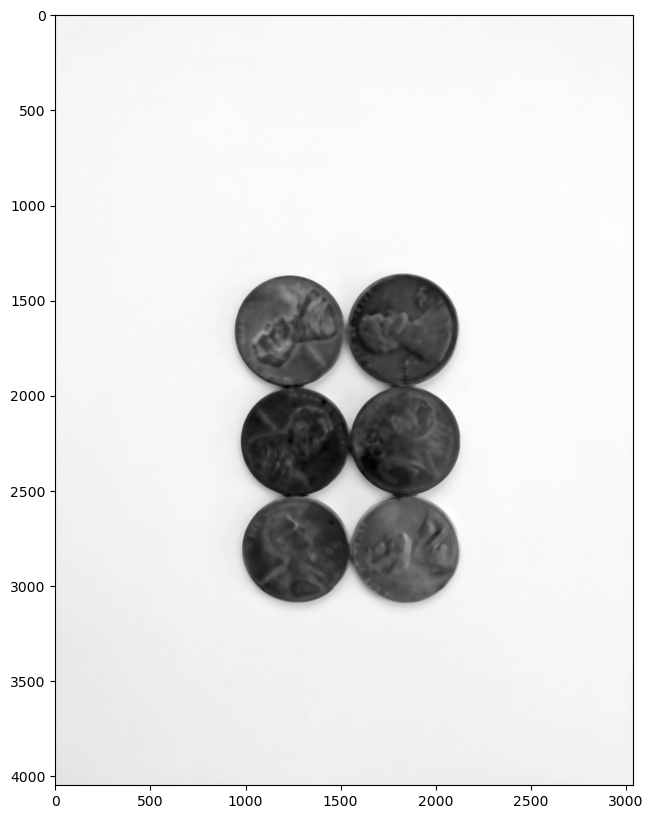

In [22]:
display(sep_blur)

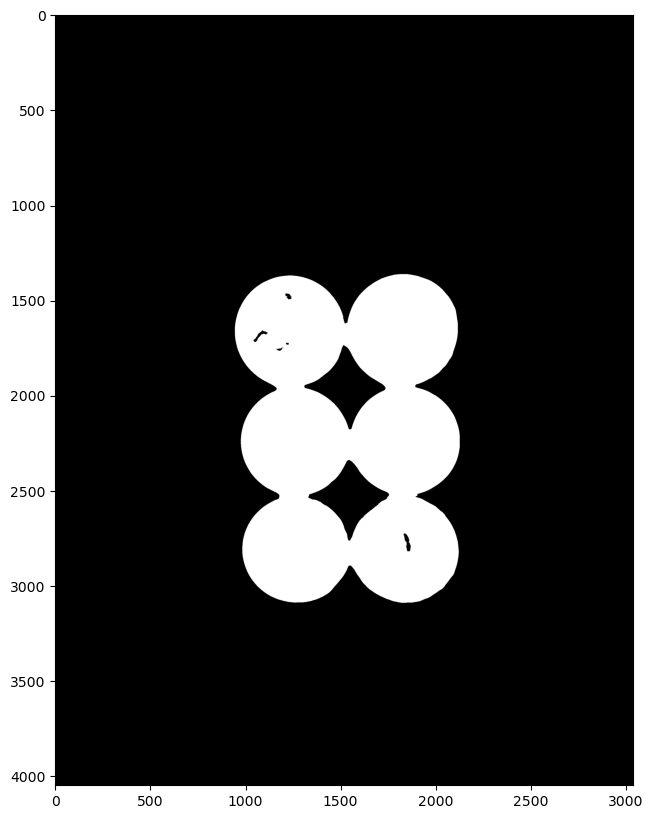

In [27]:
# Binary threshold
ret, sep_thresh = cv.threshold(sep_blur, 140, 255, cv.THRESH_BINARY_INV)
display(sep_thresh)

In [30]:
contours, hierarchy = cv.findContours(sep_thresh.copy(), cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)

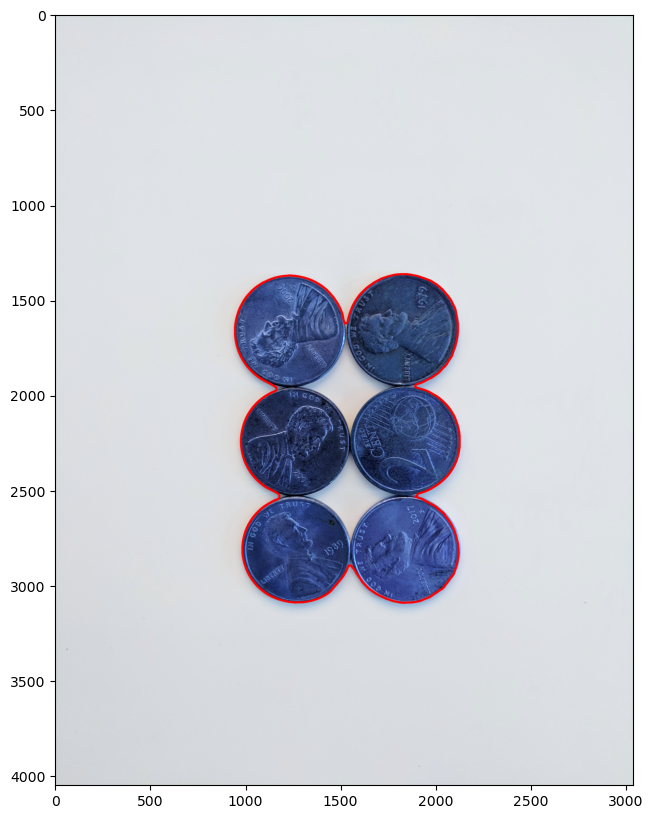

In [40]:
for i in range(len(contours)):
    if hierarchy[0][i][3] == -1:
        cv.drawContours(sep_point, contours, i, (255,0,0),10)

display(sep_point)

In [41]:
img = cv.imread('../data/pennies.jpg')

In [42]:
img = cv.medianBlur(img, ksize=35)

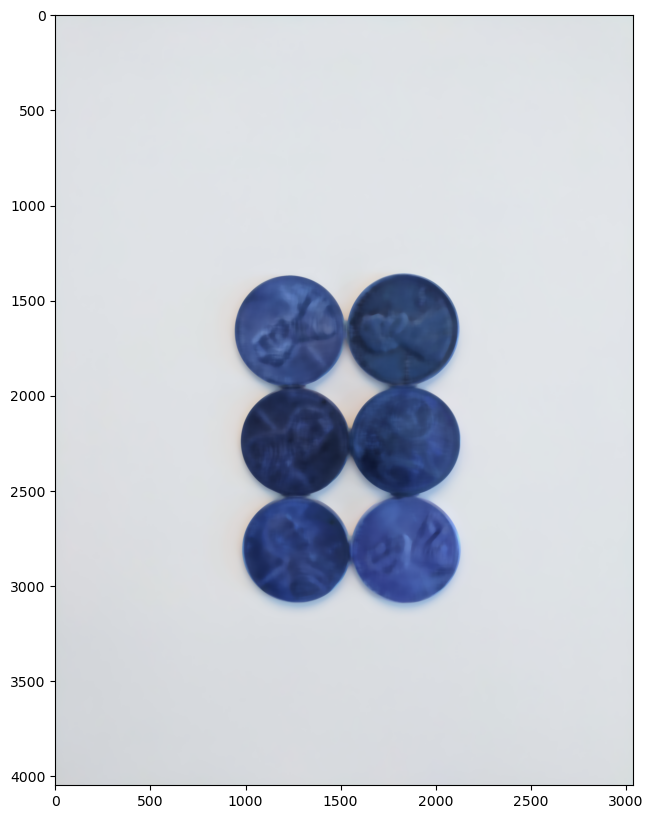

In [44]:
display(img)

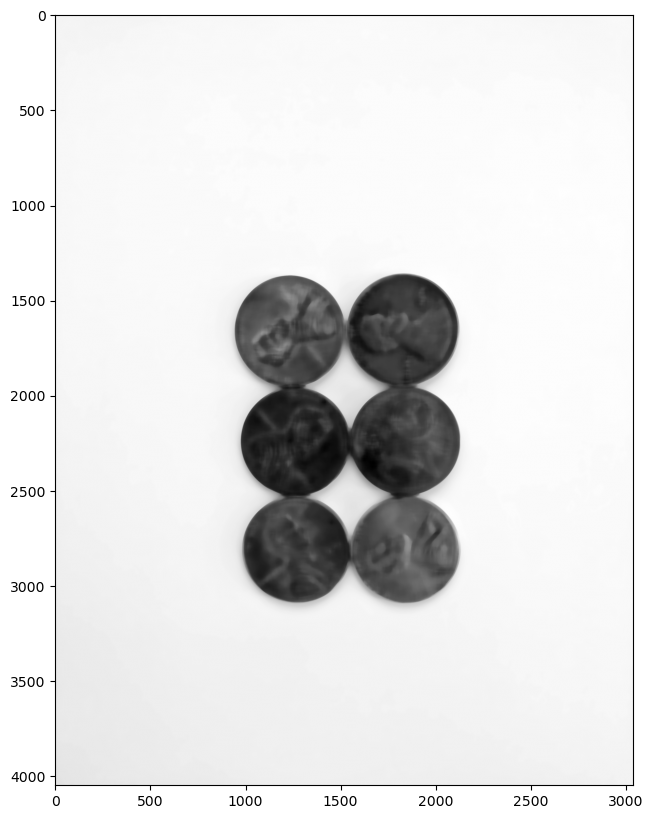

In [45]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
display(gray)

In [49]:
ret, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY_INV)

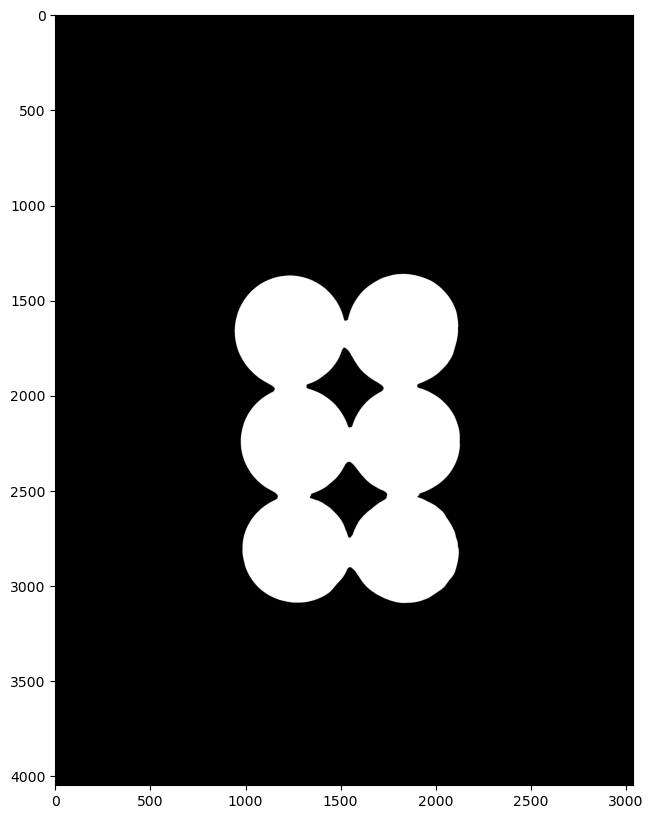

In [50]:
display(thresh)

In [51]:
# NOISE REMOVAL
kernel = np.ones((3,3), np.uint8)

In [52]:
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [53]:
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel=kernel)

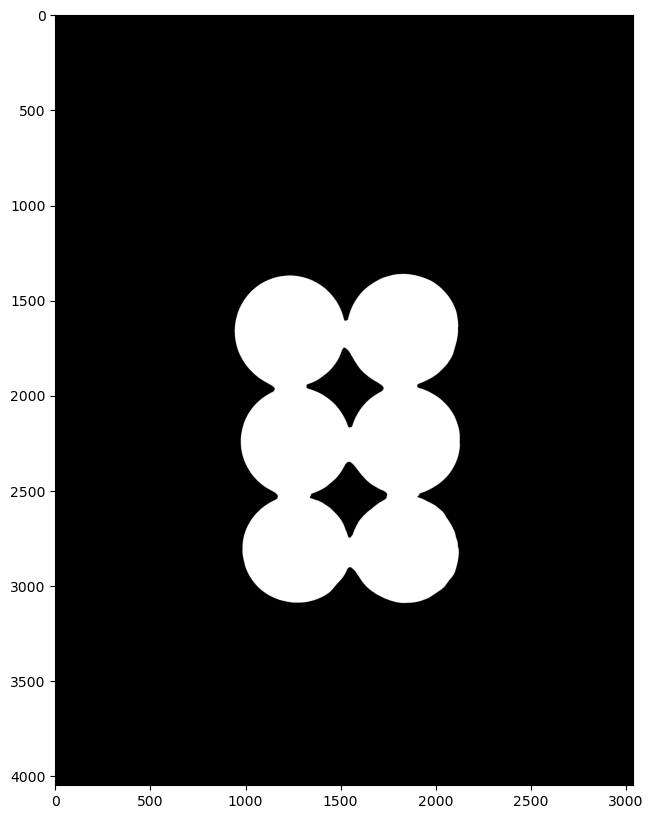

In [54]:
display(opening)

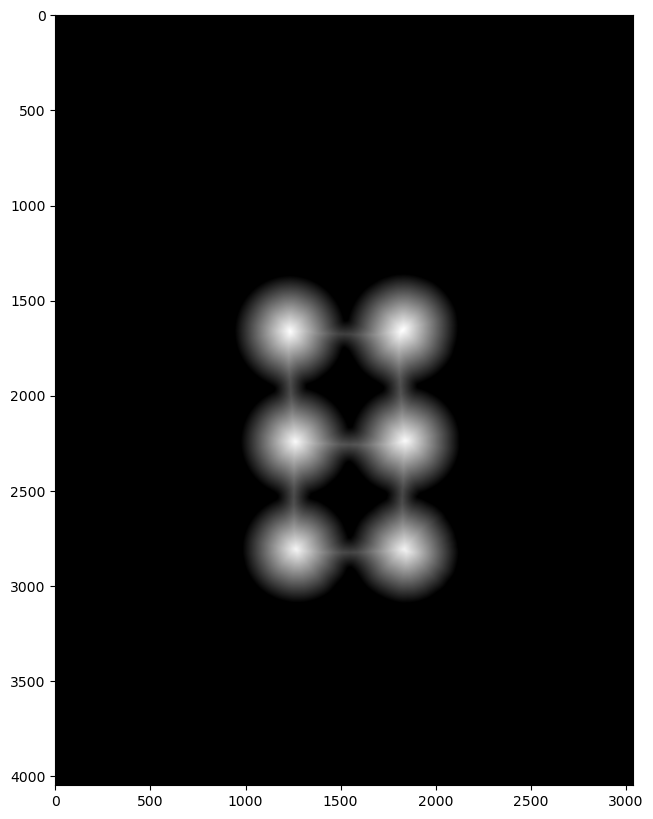

In [56]:
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
display(dist_transform)

In [57]:
ret, sure_fg = cv.threshold(dist_transform, 0.7*dist_transform.max(),255,0)

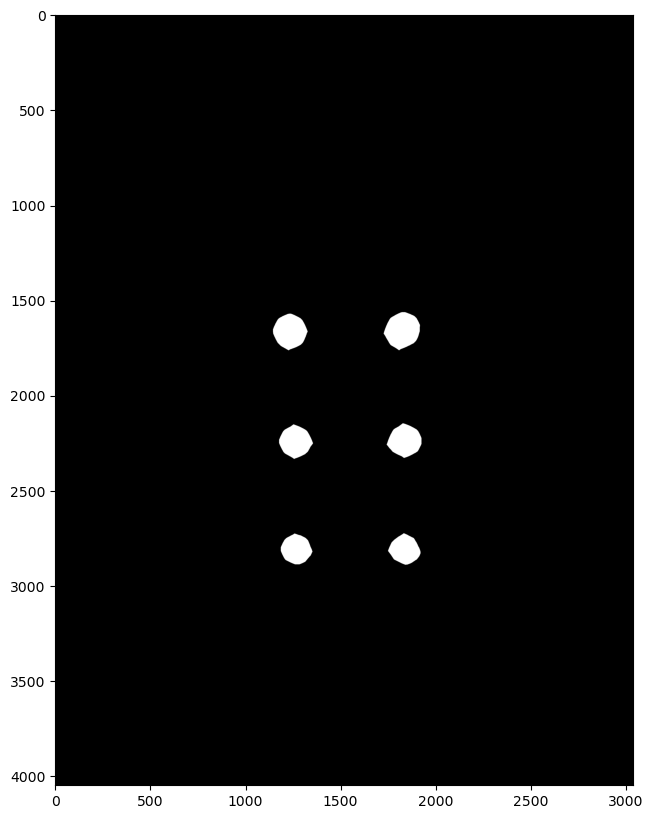

In [58]:
display(sure_fg)

In [60]:
sure_fg = np.uint8(sure_fg)
sure_bg = cv.dilate(opening, kernel, iterations=3)

In [62]:
unknown = cv.subtract(sure_bg, sure_fg)

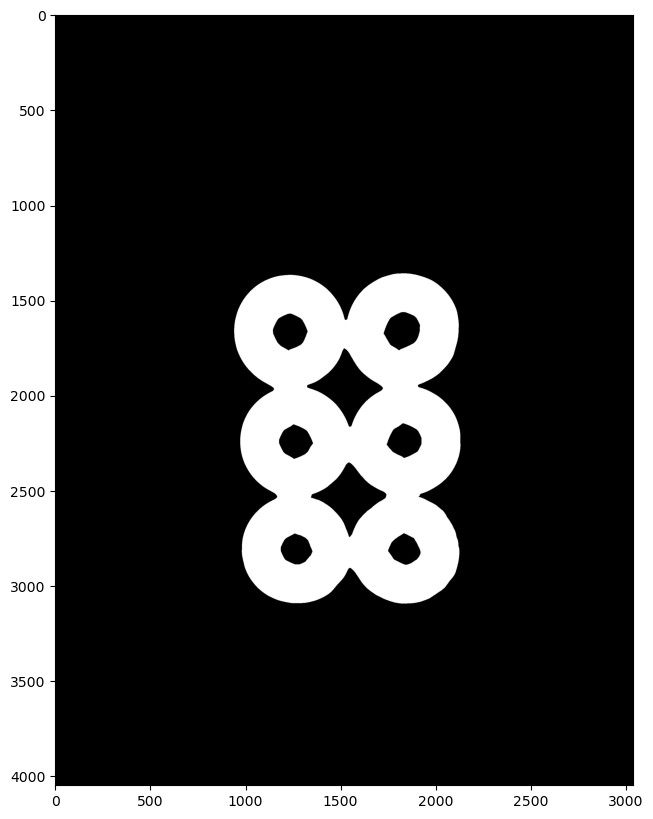

In [63]:
display(unknown)

In [73]:
ret, markers = cv.connectedComponents(sure_fg)

In [74]:
markers = markers + 1

In [75]:
markers

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(4048, 3036), dtype=int32)

In [76]:
markers[unknown==255] = 0

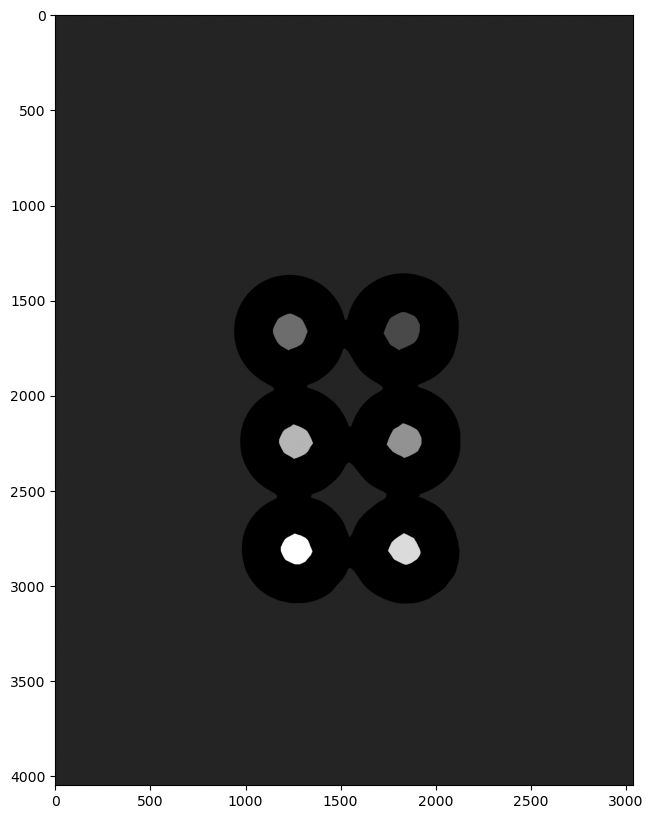

In [77]:
display(markers)